In [189]:
#STEP 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [190]:
#STEP 2: Load Dataset
df = pd.read_csv("Students Performance Dataset.csv")
df

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Mathematics,97.36,40.61,59.61,...,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9
1,S1001,Maria,Brown,student1@university.com,Male,18,Business,97.71,57.27,74.00,...,98.23,81.9170,B,27.1,No,No,High School,Low,4,4.3
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Engineering,99.52,41.84,63.85,...,91.22,67.7170,D,12.4,Yes,No,High School,Low,9,6.1
3,S1003,Omar,Williams,student3@university.com,Female,24,Engineering,90.38,45.65,44.44,...,55.48,51.6535,F,25.5,No,Yes,High School,Low,8,4.9
4,S1004,John,Smith,student4@university.com,Female,23,CS,59.41,53.13,61.77,...,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S5995,Ahmed,Jones,student4995@university.com,Male,19,CS,96.09,45.86,45.63,...,51.66,53.5470,F,7.8,No,No,Master's,Medium,10,4.5
4996,S5996,Emma,Brown,student4996@university.com,Male,19,Mathematics,96.30,78.67,47.42,...,52.33,59.0240,F,24.2,No,Yes,NaN,Medium,4,7.2
4997,S5997,John,Brown,student4997@university.com,Female,24,CS,89.94,50.84,65.83,...,97.89,74.7560,C,7.6,No,Yes,NaN,High,5,6.6
4998,S5998,Sara,Davis,student4998@university.com,Male,23,Engineering,99.09,55.44,57.45,...,84.74,68.6585,D,14.5,Yes,No,PhD,Medium,10,5.9


In [191]:
#STEP 3: Dataset Information
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              5000 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             5000 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 

Index(['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age',
       'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score',
       'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score', 'Total_Score', 'Grade', 'Study_Hours_per_Week',
       'Extracurricular_Activities', 'Internet_Access_at_Home',
       'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)',
       'Sleep_Hours_per_Night'],
      dtype='object')

In [192]:
#STEP 4: Remove Unnecessary Columns
df.drop(["First_Name","Last_Name","Email"], axis=1, inplace=True)
df

,Student_ID,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Female,22,Mathematics,97.36,40.61,59.61,73.69,53.17,73.4,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9
1,S1001,Male,18,Business,97.71,57.27,74.00,74.23,98.23,88.0,98.23,81.9170,B,27.1,No,No,High School,Low,4,4.3
2,S1002,Male,24,Engineering,99.52,41.84,63.85,85.85,50.00,4.7,91.22,67.7170,D,12.4,Yes,No,High School,Low,9,6.1
3,S1003,Female,24,Engineering,90.38,45.65,44.44,68.10,66.27,4.2,55.48,51.6535,F,25.5,No,Yes,High School,Low,8,4.9
4,S1004,Female,23,CS,59.41,53.13,61.77,67.66,83.98,64.3,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S5995,Male,19,CS,96.09,45.86,45.63,74.13,81.53,9.8,51.66,53.5470,F,7.8,No,No,Master's,Medium,10,4.5
4996,S5996,Male,19,Mathematics,96.30,78.67,47.42,57.89,85.96,47.8,52.33,59.0240,F,24.2,No,Yes,NaN,Medium,4,7.2
4997,S5997,Female,24,CS,89.94,50.84,65.83,84.69,82.27,7.5,97.89,74.7560,C,7.6,No,Yes,NaN,High,5,6.6
4998,S5998,Male,23,Engineering,99.09,55.44,57.45,78.78,55.96,62.9,84.74,68.6585,D,14.5,Yes,No,PhD,Medium,10,5.9


In [193]:
#STEP 5: Check Missing Values
print("Missing values BEFORE handling:\n")
print(df.isnull().sum())

Missing values BEFORE handling:

Student_ID                       0
Gender                           0
Age                              0
Department                       0
Attendance (%)                   0
Midterm_Score                    0
Final_Score                      0
Assignments_Avg                  0
Quizzes_Avg                      0
Participation_Score              0
Projects_Score                   0
Total_Score                      0
Grade                            0
Study_Hours_per_Week             0
Extracurricular_Activities       0
Internet_Access_at_Home          0
Parent_Education_Level        1025
Family_Income_Level              0
Stress_Level (1-10)              0
Sleep_Hours_per_Night            0
dtype: int64


In [194]:
#STEP 6: Handle Missing Values
#Categorical columns → mode
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:

    mode_value = df[col].mode()[0]

    print(f"Replacing missing values in '{col}' with MODE:", mode_value)

    df[col].fillna(mode_value, inplace=True)

Replacing missing values in 'Student_ID' with MODE: S1000
Replacing missing values in 'Gender' with MODE: Male
Replacing missing values in 'Department' with MODE: Engineering
Replacing missing values in 'Grade' with MODE: C
Replacing missing values in 'Extracurricular_Activities' with MODE: Yes
Replacing missing values in 'Internet_Access_at_Home' with MODE: Yes
Replacing missing values in 'Parent_Education_Level' with MODE: Bachelor's
Replacing missing values in 'Family_Income_Level' with MODE: Low


/tmp/ipykernel_11451/2110084116.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)


In [195]:
#Numeric columns → median
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:

    median_value = df[col].median()

    print(f"Replacing missing values in '{col}' with MEDIAN:", median_value)

    df[col].fillna(median_value, inplace=True)

Replacing missing values in 'Age' with MEDIAN: 21.0
Replacing missing values in 'Attendance (%)' with MEDIAN: 75.67
Replacing missing values in 'Midterm_Score' with MEDIAN: 70.86
Replacing missing values in 'Final_Score' with MEDIAN: 69.485
Replacing missing values in 'Assignments_Avg' with MEDIAN: 75.09
Replacing missing values in 'Quizzes_Avg' with MEDIAN: 74.905
Replacing missing values in 'Participation_Score' with MEDIAN: 49.6
Replacing missing values in 'Projects_Score' with MEDIAN: 74.54
Replacing missing values in 'Total_Score' with MEDIAN: 71.69625
Replacing missing values in 'Study_Hours_per_Week' with MEDIAN: 17.4
Replacing missing values in 'Stress_Level (1-10)' with MEDIAN: 6.0
Replacing missing values in 'Sleep_Hours_per_Night' with MEDIAN: 6.5


/tmp/ipykernel_11451/2668909905.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)


In [196]:
df

,Student_ID,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Female,22,Mathematics,97.36,40.61,59.61,73.69,53.17,73.4,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9
1,S1001,Male,18,Business,97.71,57.27,74.00,74.23,98.23,88.0,98.23,81.9170,B,27.1,No,No,High School,Low,4,4.3
2,S1002,Male,24,Engineering,99.52,41.84,63.85,85.85,50.00,4.7,91.22,67.7170,D,12.4,Yes,No,High School,Low,9,6.1
3,S1003,Female,24,Engineering,90.38,45.65,44.44,68.10,66.27,4.2,55.48,51.6535,F,25.5,No,Yes,High School,Low,8,4.9
4,S1004,Female,23,CS,59.41,53.13,61.77,67.66,83.98,64.3,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S5995,Male,19,CS,96.09,45.86,45.63,74.13,81.53,9.8,51.66,53.5470,F,7.8,No,No,Master's,Medium,10,4.5
4996,S5996,Male,19,Mathematics,96.30,78.67,47.42,57.89,85.96,47.8,52.33,59.0240,F,24.2,No,Yes,Bachelor's,Medium,4,7.2
4997,S5997,Female,24,CS,89.94,50.84,65.83,84.69,82.27,7.5,97.89,74.7560,C,7.6,No,Yes,Bachelor's,High,5,6.6
4998,S5998,Male,23,Engineering,99.09,55.44,57.45,78.78,55.96,62.9,84.74,68.6585,D,14.5,Yes,No,PhD,Medium,10,5.9


In [197]:
print("\nMissing values AFTER handling:\n")
print(df.isnull().sum())


Missing values AFTER handling:

Student_ID                    0
Gender                        0
Age                           0
Department                    0
Attendance (%)                0
Midterm_Score                 0
Final_Score                   0
Assignments_Avg               0
Quizzes_Avg                   0
Participation_Score           0
Projects_Score                0
Total_Score                   0
Grade                         0
Study_Hours_per_Week          0
Extracurricular_Activities    0
Internet_Access_at_Home       0
Parent_Education_Level        0
Family_Income_Level           0
Stress_Level (1-10)           0
Sleep_Hours_per_Night         0
dtype: int64


In [198]:
#STEP 7: Outlier Detection
#Select numeric columns

numeric_cols = df.select_dtypes(include=np.number).columns

numeric_cols

Index(['Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score',
       'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score', 'Total_Score', 'Study_Hours_per_Week',
       'Stress_Level (1-10)', 'Sleep_Hours_per_Night'],
      dtype='object')

In [199]:
# Detect outliers using box plot
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = ((df[numeric_cols] < lower_limit) |
            (df[numeric_cols] > upper_limit)).sum()

print("Outliers in each column:\n")
print(outliers)

Outliers in each column:

Age                      0
Attendance (%)           0
Midterm_Score            0
Final_Score              0
Assignments_Avg          0
Quizzes_Avg              0
Participation_Score      0
Projects_Score           0
Total_Score              4
Study_Hours_per_Week     0
Stress_Level (1-10)      0
Sleep_Hours_per_Night    0
dtype: int64


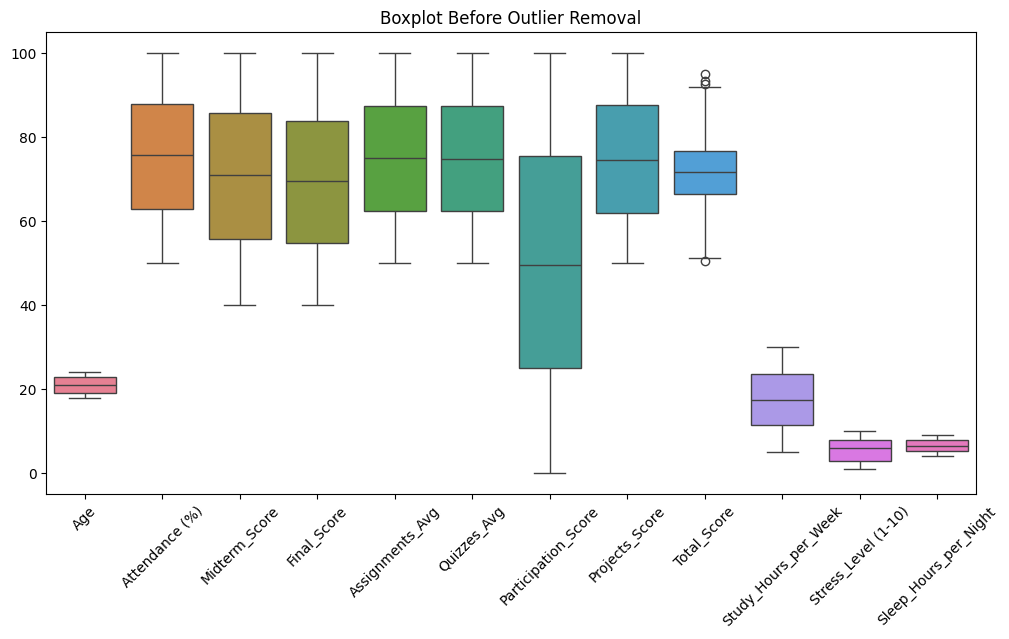

In [200]:
#Visualize outliers using boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot Before Outlier Removal")
plt.xticks(rotation=45)
plt.show()

In [201]:
#Step 8:Remove outliers using IQR method
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper, upper,
                       np.where(df[col] < lower, lower, df[col]))

print("Outliers handled successfully ✅")

Outliers handled successfully ✅


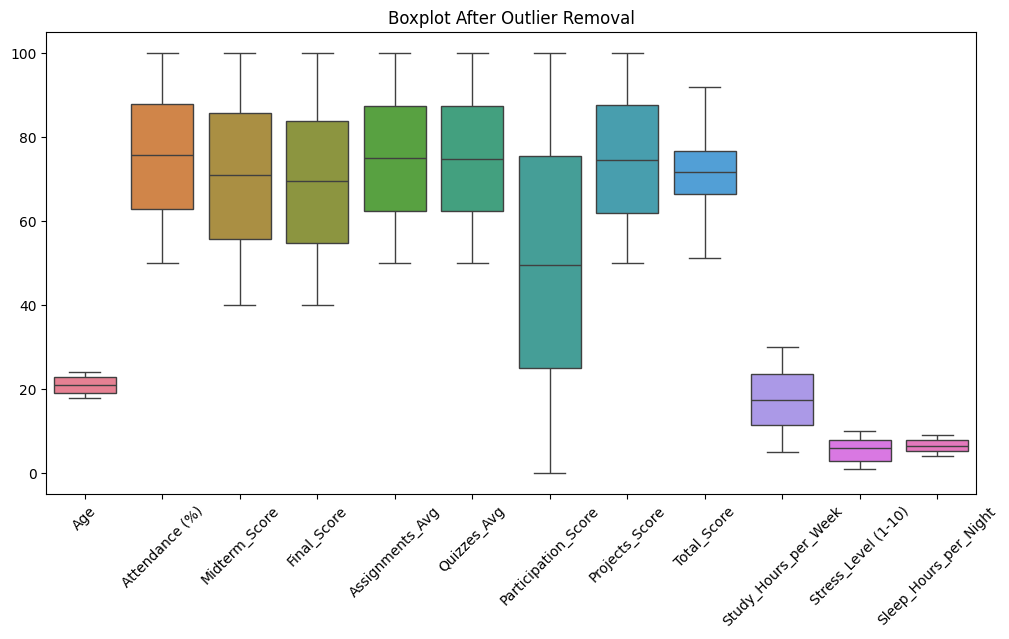

In [202]:
#Verify outliers after removal
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot After Outlier Removal")
plt.xticks(rotation=45)
plt.show()

In [203]:
#Show before vs after comparison
df_before = df.copy()
Q1_new = df[numeric_cols].quantile(0.25)
Q3_new = df[numeric_cols].quantile(0.75)

IQR_new = Q3_new - Q1_new

outliers_after = ((df[numeric_cols] < (Q1_new - 1.5*IQR_new)) |
                  (df[numeric_cols] > (Q3_new + 1.5*IQR_new))).sum()

print("Outliers after treatment:\n")
print(outliers_after)

Outliers after treatment:

Age                      0
Attendance (%)           0
Midterm_Score            0
Final_Score              0
Assignments_Avg          0
Quizzes_Avg              0
Participation_Score      0
Projects_Score           0
Total_Score              0
Study_Hours_per_Week     0
Stress_Level (1-10)      0
Sleep_Hours_per_Night    0
dtype: int64


In [204]:
#Step 9:Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df.copy()

cols_to_scale = [
    "Midterm_Score",
    "Final_Score",
    "Assignments_Avg",
    "Quizzes_Avg",
    "Participation_Score",
    "Projects_Score",
    "Total_Score"
]

df_standardized[cols_to_scale] = scaler.fit_transform(df_standardized[cols_to_scale])

df_standardized

,Student_ID,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Female,22.0,Mathematics,97.36,-1.725991,-0.580837,-0.087922,-1.502261,0.808513,-0.821338,-1.628120,F,10.3,Yes,No,Master's,Medium,1.0,5.9
1,S1001,Male,18.0,Business,97.71,-0.770419,0.260325,-0.050429,1.622045,1.312189,1.612474,1.420685,B,27.1,No,No,High School,Low,4.0,4.3
2,S1002,Male,24.0,Engineering,99.52,-1.655441,-0.332990,0.756356,-1.722058,-1.561524,1.130388,-0.544455,D,12.4,Yes,No,High School,Low,9.0,6.1
3,S1003,Female,24.0,Engineering,90.38,-1.436910,-1.467594,-0.476039,-0.593952,-1.578773,-1.327493,-2.767486,F,25.5,No,Yes,High School,Low,8.0,4.9
4,S1004,Female,23.0,CS,59.41,-1.007878,-0.454575,-0.506589,0.633999,0.494578,0.869746,-0.034349,C,13.3,Yes,No,Master's,Medium,6.0,4.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S5995,Male,19.0,CS,96.09,-1.424865,-1.398033,-0.057372,0.464124,-1.385582,-1.590199,-2.505445,F,7.8,No,No,Master's,Medium,10.0,4.5
4996,S5996,Male,19.0,Mathematics,96.30,0.457027,-1.293399,-1.184927,0.771285,-0.074645,-1.544123,-1.747481,F,24.2,No,Yes,Bachelor's,Medium,4.0,7.2
4997,S5997,Female,24.0,CS,89.94,-1.139226,-0.217250,0.675816,0.515433,-1.464929,1.589092,0.429673,C,7.6,No,Yes,Bachelor's,High,5.0,6.6
4998,S5998,Male,23.0,Engineering,99.09,-0.875382,-0.707099,0.265481,-1.308812,0.446280,0.684751,-0.414161,D,14.5,Yes,No,PhD,Medium,10.0,5.9


In [205]:
#Step 10:Normalization
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

df_normalized = df.copy()

df_normalized[cols_to_scale] = minmax.fit_transform(df_normalized[cols_to_scale])

df_normalized.head()

,Student_ID,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Female,22.0,Mathematics,97.36,0.010168,0.326830,0.473895,0.063413,0.734,0.2568,0.211718,F,10.3,Yes,No,Master's,Medium,1.0,5.9
1,S1001,Male,18.0,Business,97.71,0.287881,0.566783,0.484697,0.964793,0.880,0.9646,0.752862,B,27.1,No,No,High School,Low,4.0,4.3
2,S1002,Male,24.0,Engineering,99.52,0.030672,0.397532,0.717143,0.000000,0.047,0.8244,0.404062,D,12.4,Yes,No,High School,Low,9.0,6.1
3,S1003,Female,24.0,Engineering,90.38,0.094182,0.073870,0.362072,0.325465,0.042,0.1096,0.009488,F,25.5,No,Yes,High School,Low,8.0,4.9
4,S1004,Female,23.0,CS,59.41,0.218870,0.362848,0.353271,0.679736,0.643,0.7486,0.494602,C,13.3,Yes,No,Master's,Medium,6.0,4.5


In [206]:
#Show comparison
print("Original Values:\n")
display(df[cols_to_scale].head())

print("Standardized Values:\n")
display(df_standardized[cols_to_scale].head())

print("Normalized Values:\n")
display(df_normalized[cols_to_scale].head())





Original Values:



,Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score
0,40.61,59.61,73.69,53.17,73.4,62.84,59.8865
1,57.27,74.00,74.23,98.23,88.0,98.23,81.9170
2,41.84,63.85,85.85,50.00,4.7,91.22,67.7170
3,45.65,44.44,68.10,66.27,4.2,55.48,51.6535
4,53.13,61.77,67.66,83.98,64.3,87.43,71.4030


Standardized Values:



,Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score
0,-1.725991,-0.580837,-0.087922,-1.502261,0.808513,-0.821338,-1.628120
1,-0.770419,0.260325,-0.050429,1.622045,1.312189,1.612474,1.420685
2,-1.655441,-0.332990,0.756356,-1.722058,-1.561524,1.130388,-0.544455
3,-1.436910,-1.467594,-0.476039,-0.593952,-1.578773,-1.327493,-2.767486
4,-1.007878,-0.454575,-0.506589,0.633999,0.494578,0.869746,-0.034349


Normalized Values:



,Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score
0,0.010168,0.326830,0.473895,0.063413,0.734,0.2568,0.211718
1,0.287881,0.566783,0.484697,0.964793,0.880,0.9646,0.752862
2,0.030672,0.397532,0.717143,0.000000,0.047,0.8244,0.404062
3,0.094182,0.073870,0.362072,0.325465,0.042,0.1096,0.009488
4,0.218870,0.362848,0.353271,0.679736,0.643,0.7486,0.494602


In [207]:
#Encoding Techniques
#Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

label_cols = [
    "Gender",
    "Internet_Access_at_Home",
    "Extracurricular_Activities",
    "Grade",
    "Parent_Education_Level",
    "Family_Income_Level"
]
for col in label_cols:
    df[col] = le.fit_transform(df[col])
df.head()

,Student_ID,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,0,22.0,Mathematics,97.36,40.61,59.61,73.69,53.17,73.4,62.84,59.8865,4,10.3,1,0,2,2,1.0,5.9
1,S1001,1,18.0,Business,97.71,57.27,74.00,74.23,98.23,88.0,98.23,81.9170,1,27.1,0,0,1,1,4.0,4.3
2,S1002,1,24.0,Engineering,99.52,41.84,63.85,85.85,50.00,4.7,91.22,67.7170,3,12.4,1,0,1,1,9.0,6.1
3,S1003,0,24.0,Engineering,90.38,45.65,44.44,68.10,66.27,4.2,55.48,51.6535,4,25.5,0,1,1,1,8.0,4.9
4,S1004,0,23.0,CS,59.41,53.13,61.77,67.66,83.98,64.3,87.43,71.4030,2,13.3,1,0,2,2,6.0,4.5


In [208]:
#Step 11:One-Hot Encoding (for Department column)
df = pd.get_dummies(df, columns=["Department"], drop_first=True, dtype=int)

df.head()



,Student_ID,Gender,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,...,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Department_CS,Department_Engineering,Department_Mathematics
0,S1000,0,22.0,97.36,40.61,59.61,73.69,53.17,73.4,62.84,...,10.3,1,0,2,2,1.0,5.9,0,0,1
1,S1001,1,18.0,97.71,57.27,74.00,74.23,98.23,88.0,98.23,...,27.1,0,0,1,1,4.0,4.3,0,0,0
2,S1002,1,24.0,99.52,41.84,63.85,85.85,50.00,4.7,91.22,...,12.4,1,0,1,1,9.0,6.1,0,1,0
3,S1003,0,24.0,90.38,45.65,44.44,68.10,66.27,4.2,55.48,...,25.5,0,1,1,1,8.0,4.9,0,1,0
4,S1004,0,23.0,59.41,53.13,61.77,67.66,83.98,64.3,87.43,...,13.3,1,0,2,2,6.0,4.5,1,0,0


In [209]:
#Verify encoding completed
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   Gender                      5000 non-null   int64  
 2   Age                         5000 non-null   float64
 3   Attendance (%)              5000 non-null   float64
 4   Midterm_Score               5000 non-null   float64
 5   Final_Score                 5000 non-null   float64
 6   Assignments_Avg             5000 non-null   float64
 7   Quizzes_Avg                 5000 non-null   float64
 8   Participation_Score         5000 non-null   float64
 9   Projects_Score              5000 non-null   float64
 10  Total_Score                 5000 non-null   float64
 11  Grade                       5000 non-null   int64  
 12  Study_Hours_per_Week        5000 non-null   float64
 13  Extracurricular_Activities  5000 

In [211]:
#Step 13:Save Final Clean Dataset
df.to_csv("Final_Cleaned_Dataset.csv", index=False)
df

,Student_ID,Gender,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,...,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Department_CS,Department_Engineering,Department_Mathematics
0,S1000,0,22.0,97.36,40.61,59.61,73.69,53.17,73.4,62.84,...,10.3,1,0,2,2,1.0,5.9,0,0,1
1,S1001,1,18.0,97.71,57.27,74.00,74.23,98.23,88.0,98.23,...,27.1,0,0,1,1,4.0,4.3,0,0,0
2,S1002,1,24.0,99.52,41.84,63.85,85.85,50.00,4.7,91.22,...,12.4,1,0,1,1,9.0,6.1,0,1,0
3,S1003,0,24.0,90.38,45.65,44.44,68.10,66.27,4.2,55.48,...,25.5,0,1,1,1,8.0,4.9,0,1,0
4,S1004,0,23.0,59.41,53.13,61.77,67.66,83.98,64.3,87.43,...,13.3,1,0,2,2,6.0,4.5,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S5995,1,19.0,96.09,45.86,45.63,74.13,81.53,9.8,51.66,...,7.8,0,0,2,2,10.0,4.5,1,0,0
4996,S5996,1,19.0,96.30,78.67,47.42,57.89,85.96,47.8,52.33,...,24.2,0,1,0,2,4.0,7.2,0,0,1
4997,S5997,0,24.0,89.94,50.84,65.83,84.69,82.27,7.5,97.89,...,7.6,0,1,0,0,5.0,6.6,1,0,0
4998,S5998,1,23.0,99.09,55.44,57.45,78.78,55.96,62.9,84.74,...,14.5,1,0,3,2,10.0,5.9,0,1,0


In [212]:
#Download:
files.download("Final_Cleaned_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>